# Autonomous Racing Car - Continue Training
Load existing `model.pth` and continue training to improve the agent.
Upload your `model.pth` to Kaggle or place it in the same directory.

In [7]:
import math, random, os, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque, defaultdict

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    NUM_CARS, BATCH_SIZE, BUFFER_CAP, TPS = 1000, 1024, 1_000_000, 16
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    if torch.cuda.device_count() > 1:
        print(f'GPUs available: {torch.cuda.device_count()}')
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM: {vram:.1f} GB')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    NUM_CARS, BATCH_SIZE, BUFFER_CAP, TPS = 500, 256, 500_000, 10
else:
    DEVICE = torch.device('cpu')
    NUM_CARS, BATCH_SIZE, BUFFER_CAP, TPS = 200, 128, 300_000, 6

LR = 3e-4
GAMMA = 0.99
N_STEP = 3
GAMMA_N = GAMMA ** N_STEP
SOFT_TAU = 0.005
MAX_SPEED = 8.0
ACCEL = 0.3
BRAKE = 0.5
FRIC = 0.05
TURN = 4.0
SENS_LEN = 200
N_SENS = 9
CAR_W, CAR_H = 20, 40
MAX_STEPS = 2000
STATE_SIZE = N_SENS + 3
ACTION_SIZE = 5
MODEL_PATH = 'model.pth'
NUM_EPISODES = 1
SAVE_EVERY = 100_000

print(f'Device: {DEVICE} | Cars: {NUM_CARS} | Batch: {BATCH_SIZE} | Buffer: {BUFFER_CAP:,} | Train/step: {TPS}')

Device: mps | Cars: 500 | Batch: 256 | Buffer: 500,000 | Train/step: 10


In [8]:
class Track:
    def __init__(self):
        cx, cy = 700, 450
        self.outer = [
            (cx-650,cy+50),(cx-640,cy-20),(cx-580,cy-80),(cx-450,cy-120),
            (cx-200,cy-130),(cx+100,cy-120),(cx+350,cy-150),(cx+550,cy-250),
            (cx+640,cy-150),(cx+620,cy+20),(cx+550,cy+120),(cx+400,cy+180),
            (cx+200,cy+150),(cx+50,cy+120),(cx-50,cy+180),(cx-200,cy+250),
            (cx-400,cy+280),(cx-550,cy+220),(cx-620,cy+150),
        ]
        self.inner = [
            (cx-540,cy+50),(cx-530,cy+20),(cx-470,cy-20),(cx-340,cy-30),
            (cx-110,cy-40),(cx+100,cy-20),(cx+280,cy-50),(cx+420,cy-120),
            (cx+510,cy-50),(cx+500,cy+20),(cx+440,cy+40),(cx+310,cy+90),
            (cx+130,cy+60),(cx-10,cy+30),(cx-50,cy+80),(cx-120,cy+160),
            (cx-310,cy+190),(cx-450,cy+140),(cx-520,cy+90),
        ]
        self.walls = []
        for pts in [self.outer, self.inner]:
            for i in range(len(pts)):
                self.walls.append((pts[i], pts[(i+1) % len(pts)]))
        self.checkpoints = [(self.outer[i], self.inner[i]) for i in range(len(self.outer))]

class Env:
    def __init__(self, num_cars=NUM_CARS):
        track = Track()
        self.nc = num_cars
        self.ms = MAX_STEPS
        self.ncp = len(track.checkpoints)
        self.wp1 = np.array([w[0] for w in track.walls], dtype=np.float64)
        self.wp2 = np.array([w[1] for w in track.walls], dtype=np.float64)
        self.cpp1 = np.array([c[0] for c in track.checkpoints], dtype=np.float64)
        self.cpp2 = np.array([c[1] for c in track.checkpoints], dtype=np.float64)
        self.sa_arr = np.array([-90, -67.5, -45, -22.5, 0, 22.5, 45, 67.5, 90])
        N = num_cars
        self.sx = np.zeros(N); self.sy = np.zeros(N)
        self.sang = np.zeros(N); self.scp = np.zeros(N, dtype=np.int64)
        for i in range(N):
            ci = i % self.ncp
            cp = track.checkpoints[ci]
            self.sx[i] = (cp[0][0]+cp[1][0])/2
            self.sy[i] = (cp[0][1]+cp[1][1])/2
            nxt = track.checkpoints[(ci+1)%self.ncp]
            nx, ny = (nxt[0][0]+nxt[1][0])/2, (nxt[0][1]+nxt[1][1])/2
            self.sang[i] = math.degrees(math.atan2(-(ny-self.sy[i]), nx-self.sx[i]))
            self.scp[i] = (ci+1) % self.ncp
        self._init_state()

    def _init_state(self):
        N = self.nc
        self.x = self.sx.copy(); self.y = self.sy.copy()
        self.ang = self.sang.copy(); self.spd = np.zeros(N)
        self.alive = np.ones(N, dtype=bool)
        self.tm = np.zeros(N, dtype=np.int64)
        self.cp = self.scp.copy(); self.cpp = np.zeros(N, dtype=np.int64)
        self.sens = np.ones((N, N_SENS))
        self.px = self.sx.copy(); self.py = self.sy.copy()
        self.idle = np.zeros(N, dtype=np.int64)
        self.lct = np.zeros(N, dtype=np.int64)
        self.steps = np.zeros(N, dtype=np.int64)
        self.rews = np.zeros(N); self.dn = np.zeros(N, dtype=bool)
        self.gs = 0

    def _isect(self, ax1, ay1, ax2, ay2, bx1, by1, bx2, by2):
        d = (ax1-ax2)*(by1-by2) - (ay1-ay2)*(bx1-bx2)
        sd = np.where(np.abs(d) < 1e-10, 1.0, d)
        t = ((ax1-bx1)*(by1-by2) - (ay1-by1)*(bx1-bx2)) / sd
        u = -((ax1-ax2)*(ay1-by1) - (ay1-ay2)*(ax1-bx1)) / sd
        ok = (np.abs(d) > 1e-10) & (t >= 0) & (t <= 1) & (u >= 0) & (u <= 1)
        return ok, t

    def _cast(self):
        a = np.radians(self.ang[:, None] + self.sa_arr[None, :])
        ex = self.x[:, None] + SENS_LEN * np.cos(a)
        ey = self.y[:, None] - SENS_LEN * np.sin(a)
        ok, t = self._isect(
            self.x[:, None, None], self.y[:, None, None],
            ex[:, :, None], ey[:, :, None],
            self.wp1[None, None, :, 0], self.wp1[None, None, :, 1],
            self.wp2[None, None, :, 0], self.wp2[None, None, :, 1])
        self.sens = np.min(np.where(ok, t, 1.0), axis=2)

    def _corners(self):
        r = np.radians(self.ang)
        c, s = np.cos(r), np.sin(r)
        hw, hh = CAR_W / 2, CAR_H / 2
        cx = np.stack([self.x+c*hh-s*hw, self.x+c*hh+s*hw,
                        self.x-c*hh+s*hw, self.x-c*hh-s*hw], axis=1)
        cy = np.stack([self.y-s*hh-c*hw, self.y-s*hh+c*hw,
                        self.y+s*hh+c*hw, self.y+s*hh-c*hw], axis=1)
        return cx, cy

    def _col(self):
        cx, cy = self._corners()
        ncx, ncy = np.roll(cx, -1, axis=1), np.roll(cy, -1, axis=1)
        ok, _ = self._isect(
            cx[:, :, None], cy[:, :, None],
            ncx[:, :, None], ncy[:, :, None],
            self.wp1[None, None, :, 0], self.wp1[None, None, :, 1],
            self.wp2[None, None, :, 0], self.wp2[None, None, :, 1])
        return ok.any(axis=(1, 2))

    def _chkcp(self):
        cx, cy = self._corners()
        ncx, ncy = np.roll(cx, -1, axis=1), np.roll(cy, -1, axis=1)
        ti = self.cp % self.ncp
        ok, _ = self._isect(
            cx, cy, ncx, ncy,
            self.cpp1[ti, 0][:, None], self.cpp1[ti, 1][:, None],
            self.cpp2[ti, 0][:, None], self.cpp2[ti, 1][:, None])
        return ok.any(axis=1)

    def _cpd(self):
        ti = self.cp % self.ncp
        mx = (self.cpp1[ti, 0] + self.cpp2[ti, 0]) / 2
        my = (self.cpp1[ti, 1] + self.cpp2[ti, 1]) / 2
        return np.hypot(self.x - mx, self.y - my)

    def _upd(self, actions):
        a = np.asarray(actions); al = self.alive
        sf = np.maximum(0.5, self.spd / MAX_SPEED)
        m0 = (a == 0) & al; m1 = (a == 1) & al
        m2 = (a == 2) & al; m3 = (a == 3) & al
        self.spd[m0] += ACCEL; self.spd[m1] -= BRAKE
        self.ang[m2] += TURN * sf[m2]; self.spd[m2] += ACCEL * 0.7
        self.ang[m3] -= TURN * sf[m3]; self.spd[m3] += ACCEL * 0.7
        p = (self.spd > 0) & al; n = (self.spd < 0) & al
        self.spd[p] -= FRIC; self.spd[n] += FRIC
        self.spd = np.clip(self.spd, 0.0, MAX_SPEED)
        self.spd[np.abs(self.spd) < 0.01] = 0.0
        rad = np.radians(self.ang)
        self.x[al] += (self.spd * np.cos(rad))[al]
        self.y[al] -= (self.spd * np.sin(rad))[al]
        self.tm[al] += 1
        mv = np.hypot(self.x - self.px, self.y - self.py)
        ii = (mv < 1.0) & al; ni = (~ii) & al
        self.idle[ii] += 1
        self.idle[ni] = np.maximum(0, self.idle[ni] - 2)
        self.px[:] = self.x; self.py[:] = self.y

    def _rst(self, m):
        self.x[m] = self.sx[m]; self.y[m] = self.sy[m]
        self.ang[m] = self.sang[m]; self.spd[m] = 0.0
        self.alive[m] = True; self.tm[m] = 0
        self.cp[m] = self.scp[m]; self.cpp[m] = 0
        self.sens[m] = 1.0
        self.px[m] = self.sx[m]; self.py[m] = self.sy[m]
        self.idle[m] = 0; self.lct[m] = 0
        self.steps[m] = 0; self.rews[m] = 0.0; self.dn[m] = False

    def _states(self):
        return np.column_stack([
            self.sens,
            self.spd[:, None] / MAX_SPEED,
            np.sin(np.radians(self.ang))[:, None],
            np.cos(np.radians(self.ang))[:, None]])

    def reset(self):
        self._rst(np.ones(self.nc, dtype=bool))
        self._cast()
        self.gs = 0
        return self._states()

    def step(self, actions):
        self.gs += 1
        self._rst(self.dn)
        self.steps += 1
        pd = self._cpd()
        self._upd(actions)
        self._cast()
        col = self._col()
        cpc = self._chkcp()
        self.cp[cpc] += 1; self.cpp[cpc] += 1

        rw = np.zeros(self.nc); nc = ~col
        rw[col] = -10.0
        rw[cpc & nc] += 25.0
        self.lct[cpc] = self.tm[cpc]
        cd = self._cpd()
        rw[nc] += (pd[nc] - cd[nc]) * 0.15
        f = (self.spd > 0.5) & nc; sl = (self.spd <= 0.5) & nc
        rw[f] += (self.spd[f] / MAX_SPEED); rw[sl] -= 0.5
        i30 = (self.idle > 30) & nc; i15 = (self.idle > 15) & ~i30 & nc
        rw[i30] -= 2.0; rw[i15] -= 1.0
        sc = self.tm - self.lct
        s300 = (sc > 300) & nc; s150 = (sc > 150) & ~s300 & nc
        rw[s300] -= 1.5; rw[s150] -= 0.5
        ms = np.min(self.sens, axis=1)
        cl = (ms < 0.1) & nc
        rw[cl] -= (0.1 - ms[cl]) * 5.0
        to = (sc > 500) & self.alive
        self.alive[to] = False; rw[to] = -5.0
        self.alive[col] = False
        dn = col | (self.steps >= self.ms) | to
        self.dn = dn; self.rews += rw
        return self._states(), rw, dn

t0 = time.time()
_e = Env(100); _s = _e.reset()
for _ in range(100): _e.step(np.random.randint(0, 5, 100))
print(f'Environment ready: {_e.ncp} checkpoints | Benchmark: 100 cars x 100 steps in {time.time()-t0:.2f}s')

Environment ready: 19 checkpoints | Benchmark: 100 cars x 100 steps in 0.06s


In [9]:
class NoisyLinear(nn.Module):
    def __init__(self, inf, outf, sigma=0.5):
        super().__init__()
        self.inf, self.outf = inf, outf
        self.w_mu = nn.Parameter(torch.empty(outf, inf))
        self.w_sigma = nn.Parameter(torch.empty(outf, inf))
        self.register_buffer('w_eps', torch.empty(outf, inf))
        self.b_mu = nn.Parameter(torch.empty(outf))
        self.b_sigma = nn.Parameter(torch.empty(outf))
        self.register_buffer('b_eps', torch.empty(outf))
        self.sigma = sigma
        self._reset_params()
        self.reset_noise()

    def _reset_params(self):
        r = 1.0 / math.sqrt(self.inf)
        self.w_mu.data.uniform_(-r, r)
        self.w_sigma.data.fill_(self.sigma / math.sqrt(self.inf))
        self.b_mu.data.uniform_(-r, r)
        self.b_sigma.data.fill_(self.sigma / math.sqrt(self.outf))

    @staticmethod
    def _noise(size):
        x = torch.randn(size)
        return x.sign().mul_(x.abs().sqrt_())

    def reset_noise(self):
        ei = self._noise(self.inf)
        eo = self._noise(self.outf)
        self.w_eps.copy_(eo.ger(ei))
        self.b_eps.copy_(eo)

    def forward(self, x):
        if self.training:
            return F.linear(x, self.w_mu + self.w_sigma * self.w_eps, self.b_mu + self.b_sigma * self.b_eps)
        return F.linear(x, self.w_mu, self.b_mu)

class DQN(nn.Module):
    def __init__(self, ss, as_):
        super().__init__()
        self.fc1 = nn.Linear(ss, 256)
        self.bn1 = nn.LayerNorm(256)
        self.fc2 = nn.Linear(256, 256)
        self.bn2 = nn.LayerNorm(256)
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.LayerNorm(128)
        self.val = NoisyLinear(128, 1)
        self.adv = NoisyLinear(128, as_)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        v = self.val(x)
        a = self.adv(x)
        return v + (a - a.mean(dim=1, keepdim=True))

    def reset_noise(self):
        self.val.reset_noise()
        self.adv.reset_noise()

class SumTree:
    def __init__(self, cap):
        self.cap = cap
        self.tree = np.zeros(2*cap - 1)
        self.data = [None]*cap
        self.write = 0
        self.n = 0

    def _prop(self, idx, chg):
        p = (idx-1)//2
        self.tree[p] += chg
        if p != 0:
            self._prop(p, chg)

    def _get(self, idx, s):
        l = 2*idx+1
        if l >= len(self.tree):
            return idx
        if s <= self.tree[l]:
            return self._get(l, s)
        return self._get(l+1, s - self.tree[l])

    def total(self):
        return self.tree[0]

    def add(self, pri, data):
        idx = self.write + self.cap - 1
        self.data[self.write] = data
        self.update(idx, pri)
        self.write = (self.write+1) % self.cap
        if self.n < self.cap:
            self.n += 1

    def update(self, idx, pri):
        chg = pri - self.tree[idx]
        self.tree[idx] = pri
        self._prop(idx, chg)

    def get(self, s):
        idx = self._get(0, s)
        return idx, self.tree[idx], self.data[idx - self.cap + 1]

class PER:
    def __init__(self, cap, alpha=0.6, beta=0.4, bi=0.001, eps=0.01):
        self.tree = SumTree(cap)
        self.a, self.b, self.bi, self.e = alpha, beta, bi, eps
        self.mp = 1.0

    def push(self, s, a, r, ns, d):
        self.tree.add(self.mp, (s, a, r, ns, d))

    def sample(self, bs):
        ids, pris, batch = [], [], []
        seg = self.tree.total() / bs
        self.b = min(1.0, self.b + self.bi)
        for i in range(bs):
            s = np.random.uniform(seg*i, seg*(i+1))
            idx, pri, data = self.tree.get(s)
            if data is None:
                s = np.random.uniform(0, self.tree.total())
                idx, pri, data = self.tree.get(s)
                if data is None:
                    continue
            ids.append(idx)
            pris.append(pri)
            batch.append(data)
        if not batch:
            return None
        p = np.array(pris, dtype=np.float32)
        pr = p / self.tree.total()
        w = (self.tree.n * pr) ** (-self.b)
        w = (w / w.max()).astype(np.float32)
        ss, aa, rr, ns, dd = zip(*batch)
        return torch.stack(ss), torch.tensor(aa, dtype=torch.long), torch.tensor(rr, dtype=torch.float32), torch.stack(ns), torch.tensor(dd, dtype=torch.float32), ids, w

    def update_pri(self, ids, tde):
        for idx, td in zip(ids, tde):
            p = (abs(td) + self.e) ** self.a
            self.mp = max(self.mp, p)
            self.tree.update(idx, p)

    def __len__(self):
        return self.tree.n

print(f'Model: DQN {STATE_SIZE} -> 256 -> 256 -> 128 -> Noisy({ACTION_SIZE})')

Model: DQN 12 -> 256 -> 256 -> 128 -> Noisy(5)


In [10]:
def _remap_old_keys(sd):
    mapping = {
        'value_stream.': 'val.',
        'advantage_stream.': 'adv.',
        'weight_mu': 'w_mu',
        'weight_sigma': 'w_sigma',
        'weight_epsilon': 'w_eps',
        'bias_mu': 'b_mu',
        'bias_sigma': 'b_sigma',
        'bias_epsilon': 'b_eps',
    }
    new_sd = {}
    for k, v in sd.items():
        nk = k
        for old, new in mapping.items():
            nk = nk.replace(old, new)
        new_sd[nk] = v
    return new_sd

class Agent:
    def __init__(self):
        self.pnet = DQN(STATE_SIZE, ACTION_SIZE).to(DEVICE)
        self.tnet = DQN(STATE_SIZE, ACTION_SIZE).to(DEVICE)
        self.tnet.load_state_dict(self.pnet.state_dict())
        self.tnet.eval()
        self.opt = optim.Adam(self.pnet.parameters(), lr=LR)
        self.loss_fn = nn.SmoothL1Loss(reduction='none')
        self.mem = PER(BUFFER_CAP)
        self.nbufs = defaultdict(deque)
        self.tstep = 0
        self.ep = 0
        self.hi = float('-inf')

    def act(self, states, train=True):
        if train:
            self.pnet.reset_noise()
        t = torch.tensor(states, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            if not train:
                self.pnet.eval()
            q = self.pnet(t)
            if not train:
                self.pnet.train()
        return q.argmax(dim=1).tolist()

    def store(self, sts, acts, rws, nsts, dns):
        for i in range(len(sts)):
            st = torch.tensor(sts[i], dtype=torch.float32)
            ns = torch.tensor(nsts[i], dtype=torch.float32)
            self.nbufs[i].append((st, acts[i], rws[i], ns, dns[i]))
            if len(self.nbufs[i]) >= N_STEP:
                self._flush(i)
            if dns[i]:
                while self.nbufs[i]:
                    self._flush(i)

    def _flush(self, ci):
        buf = self.nbufs[ci]
        if not buf:
            return
        R, gp = 0.0, 1.0
        for j in range(len(buf)):
            _, _, r, _, d = buf[j]
            R += gp * r
            gp *= GAMMA
            if d:
                break
        f, l = buf[0], buf[-1]
        self.mem.push(f[0], f[1], R, l[3], l[4])
        buf.popleft()

    def train(self):
        if len(self.mem) < BATCH_SIZE:
            return None
        tl = 0.0
        for _ in range(TPS):
            s = self.mem.sample(BATCH_SIZE)
            if s is None:
                continue
            sts, acts, rws, nsts, dns, ids, w = s
            sts = sts.to(DEVICE)
            acts = acts.to(DEVICE)
            rws = rws.to(DEVICE)
            nsts = nsts.to(DEVICE)
            dns = dns.to(DEVICE)
            wt = torch.tensor(w, dtype=torch.float32).to(DEVICE)
            cq = self.pnet(sts).gather(1, acts.unsqueeze(1)).squeeze(1)
            with torch.no_grad():
                na = self.pnet(nsts).argmax(dim=1)
                nq = self.tnet(nsts).gather(1, na.unsqueeze(1)).squeeze(1)
                tq = rws + GAMMA_N * nq * (1-dns)
            td = (cq - tq).detach().cpu().numpy()
            self.mem.update_pri(ids, td)
            loss = (self.loss_fn(cq, tq) * wt).mean()
            self.opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(self.pnet.parameters(), 1.0)
            self.opt.step()
            for tp, pp in zip(self.tnet.parameters(), self.pnet.parameters()):
                tp.data.copy_(SOFT_TAU*pp.data + (1-SOFT_TAU)*tp.data)
            tl += loss.item()
            self.tstep += 1
        return tl / TPS

    def save(self, path=MODEL_PATH):
        torch.save({
            'pnet': self.pnet.state_dict(),
            'tnet': self.tnet.state_dict(),
            'opt': self.opt.state_dict(),
            'ep': self.ep,
            'hi': self.hi,
            'tstep': self.tstep,
        }, path)

    def load(self, path=MODEL_PATH):
        if not os.path.exists(path):
            return False
        ck = torch.load(path, map_location=DEVICE, weights_only=False)
        if 'pnet' in ck:
            self.pnet.load_state_dict(ck['pnet'])
            self.tnet.load_state_dict(ck['tnet'])
            self.opt.load_state_dict(ck['opt'])
            self.ep = ck.get('ep', 0)
            self.hi = ck.get('hi', float('-inf'))
            self.tstep = ck.get('tstep', 0)
        elif 'policy_net_state_dict' in ck:
            self.pnet.load_state_dict(_remap_old_keys(ck['policy_net_state_dict']))
            self.tnet.load_state_dict(_remap_old_keys(ck['target_net_state_dict']))
            self.ep = ck.get('episode', 0)
            self.hi = ck.get('high_score', float('-inf'))
            self.tstep = ck.get('training_step', 0)
        print(f'Loaded: ep={self.ep}, hi={self.hi:.1f}, steps={self.tstep}')
        return True

print('Agent ready')

Agent ready


In [ ]:
env = Env(NUM_CARS)
agent = Agent()

if not agent.load():
    print('No model.pth found! Upload your model or run train_from_scratch first.')
else:
    total_steps = agent.tstep
    best_scores = []
    avg_scores = []
    start_ep = agent.ep + 1
    t0 = time.time()

    print(f'Continuing from episode {start_ep}, steps={total_steps:,}')
    print(f'Training {NUM_EPISODES} more episodes with {NUM_CARS} cars...')
    print('='*70)

    for ep in range(start_ep, start_ep + NUM_EPISODES):
        states = env.reset()
        ep_rews = [0.0] * env.nc

        for step in range(MAX_STEPS):
            actions = agent.act(states)
            nstates, rewards, dones = env.step(actions)
            agent.store(states, actions, rewards, nstates, dones)
            agent.train()
            for i in range(env.nc):
                ep_rews[i] += rewards[i]
            states = nstates
            total_steps += env.nc

            if total_steps % SAVE_EVERY < env.nc:
                agent.ep = ep
                agent.hi = max(agent.hi, max(ep_rews))
                agent.save()

        best = max(ep_rews)
        avg = sum(ep_rews) / env.nc
        agent.hi = max(agent.hi, best)
        best_scores.append(best)
        avg_scores.append(avg)

        if ep % 5 == 0:
            elapsed = time.time() - t0
            sps = total_steps / max(elapsed, 1)
            print(f'Ep {ep:4d} | Best: {best:8.1f} | Avg: {avg:7.1f} | Hi: {agent.hi:8.1f} | Buf: {len(agent.mem):7d} | Steps: {total_steps:,} | {sps:.0f} s/s')

    agent.ep = ep
    agent.save()
    print('='*70)
    print(f'Training complete! Total steps: {total_steps:,} | Time: {time.time()-t0:.0f}s')

Loaded: ep=3, hi=4924.8, steps=43550
Continuing from episode 4, steps=43,550
Training 1 more episodes with 500 cars...


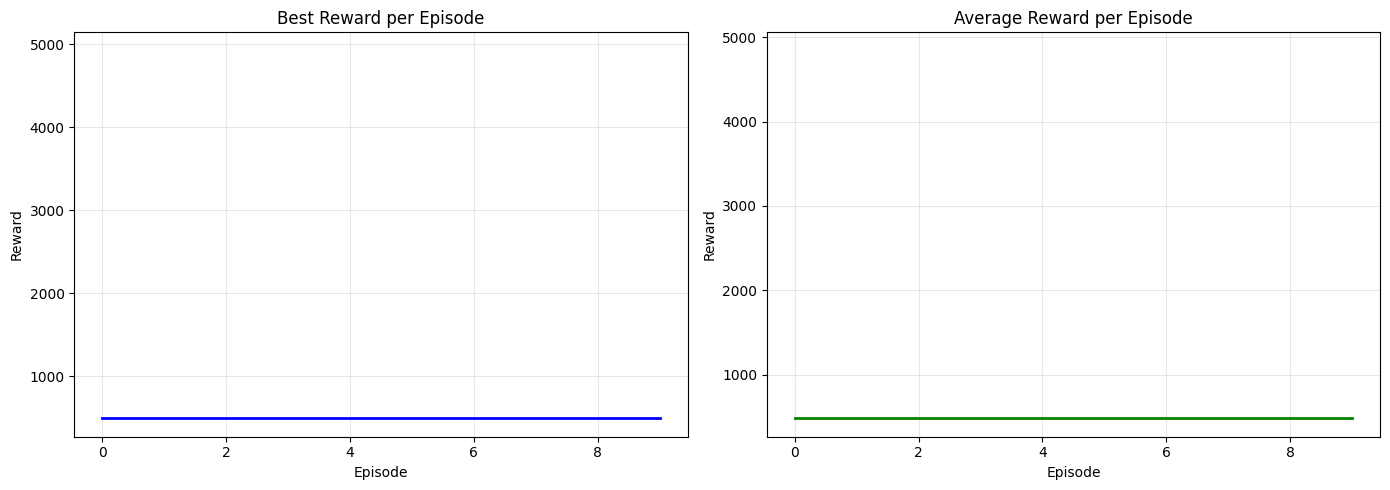

Saved training_curves.png


In [ ]:
try:
    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(best_scores, alpha=0.3, color='blue')
    ax1.plot(np.convolve(best_scores, np.ones(10)/10, mode='valid'), color='blue', linewidth=2)
    ax1.set_title('Best Reward per Episode')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Reward')
    ax1.grid(True, alpha=0.3)
    ax2.plot(avg_scores, alpha=0.3, color='green')
    ax2.plot(np.convolve(avg_scores, np.ones(10)/10, mode='valid'), color='green', linewidth=2)
    ax2.set_title('Average Reward per Episode')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Reward')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()
    print('Saved training_curves.png')
except ImportError:
    print('matplotlib not available, skipping plots')